<a href="https://colab.research.google.com/github/EkaMiharja/SMOTE_ChildrenMalnutrition_Classification/blob/main/ChildrenMalnutrition_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Library

In [1]:
# Data Processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Balancing Data
from imblearn.over_sampling import SMOTE

# Machine Learning
from sklearn.tree import DecisionTreeClassifier

# Visualisasi Tree
from sklearn.tree import plot_tree, export_text

# Model Tuning
from sklearn.model_selection import GridSearchCV

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

## 2. Import Dataset

In [4]:
df = pd.read_csv('/content/malnutrition_data (1).csv')
df

,age_months,weight_kg,height_cm,muac_cm,bmi,nutrition_status
0,12.345052,3.000000,54.134002,13.160919,10.0,normal
1,30.807200,5.459076,76.199180,13.944380,10.0,normal
2,15.723226,3.000000,60.280820,13.243565,10.0,normal
3,57.796256,10.103074,104.990471,14.105683,10.0,normal
4,40.321320,7.110583,85.277902,14.641630,10.0,normal
...,...,...,...,...,...,...
4995,36.397569,4.674426,79.668509,12.976748,10.0,moderate
4996,18.947724,3.371817,62.914947,13.806374,10.0,normal
4997,37.636794,4.504413,77.793425,12.449221,10.0,moderate
4998,27.286957,4.799405,75.048627,14.152550,10.0,normal


# a. Ukuran Dataset

In [5]:
print(df.shape)

(5000, 6)


#b. Menampilkan Nama Kolom

In [6]:
print(df.columns)

Index(['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi',
       'nutrition_status'],
      dtype='object')


# c. Menampilkan Tipe Data

In [7]:
print(df.dtypes)

age_months          float64
weight_kg           float64
height_cm           float64
muac_cm             float64
bmi                 float64
nutrition_status     object
dtype: object


# d. Menampilkan Statistik Deskriptif

In [8]:
df.describe()

,age_months,weight_kg,height_cm,muac_cm,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.329540,5.285254,75.150343,13.441465,10.004274
std,17.152432,2.340930,17.332621,0.885567,0.047272
min,1.000686,3.000000,45.000000,10.261992,10.000000
25%,15.296946,3.000000,60.180769,12.849444,10.000000
50%,30.607902,4.648996,75.010021,13.635633,10.000000
75%,45.143969,7.043410,89.366628,14.082577,10.000000
max,59.989601,10.726919,105.000000,15.715103,11.285436


# e. Melihat Jumlah Setiap Kelas

In [9]:
print(df['nutrition_status'].value_counts())

nutrition_status
normal      3550
moderate    1100
severe       350
Name: count, dtype: int64


## 3. Cleaning Data

# a. Cek Missing Value

In [10]:
print(df.isnull().sum())

age_months          0
weight_kg           0
height_cm           0
muac_cm             0
bmi                 0
nutrition_status    0
dtype: int64


# b. Cek Data Duplikat

In [11]:
print("Jumlah Duplikat:", df.duplicated().sum())

Jumlah Duplikat: 0


# c. Memastikan Nama Kolom Bersih

In [14]:
df.columns = df.columns.str.strip()

In [15]:
print(df.columns)

Index(['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi',
       'nutrition_status'],
      dtype='object')


# d. Membersihkan Label nutrition_status

In [16]:
df['nutrition_status'] = df['nutrition_status'].str.lower()
df['nutrition_status'] = df['nutrition_status'].str.strip()

# e. Validasi Umur Anak

In [18]:
df['age_months'].describe()

,age_months
count,5000.000000
mean,30.329540
std,17.152432
min,1.000686
25%,15.296946
50%,30.607902
75%,45.143969
max,59.989601


# f. Validasi Berat Badan

In [20]:
df['weight_kg'].describe()

,weight_kg
count,5000.000000
mean,5.285254
std,2.340930
min,3.000000
25%,3.000000
50%,4.648996
75%,7.043410
max,10.726919


# g. Validasi Tinggi Badan

In [22]:
df['height_cm'].describe()

,height_cm
count,5000.000000
mean,75.150343
std,17.332621
min,45.000000
25%,60.180769
50%,75.010021
75%,89.366628
max,105.000000


# h. Validasi MUAC (Lingkar Lengan Atas)

In [23]:
df['muac_cm'].describe()

,muac_cm
count,5000.000000
mean,13.441465
std,0.885567
min,10.261992
25%,12.849444
50%,13.635633
75%,14.082577
max,15.715103


# i. Validasi BMI

In [24]:
df['bmi'].describe()

,bmi
count,5000.000000
mean,10.004274
std,0.047272
min,10.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,11.285436


#j. Cek Ukuran Data Setelah Cleaning

In [25]:
print(df.shape)

(5000, 6)


## 4. Exploratory Data Analysis (EDA)

# a. Visualisasi Distribusi Status Gizi

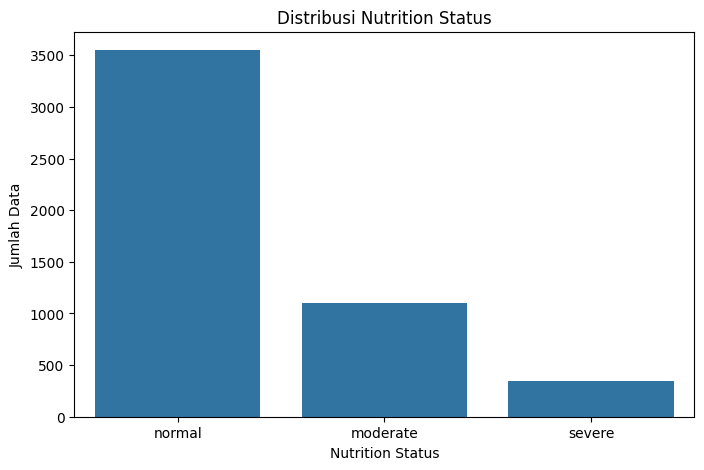

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='nutrition_status'
)

plt.title('Distribusi Nutrition Status')
plt.xlabel('Nutrition Status')
plt.ylabel('Jumlah Data')

plt.show()

# b. Distribusi Umur Anak

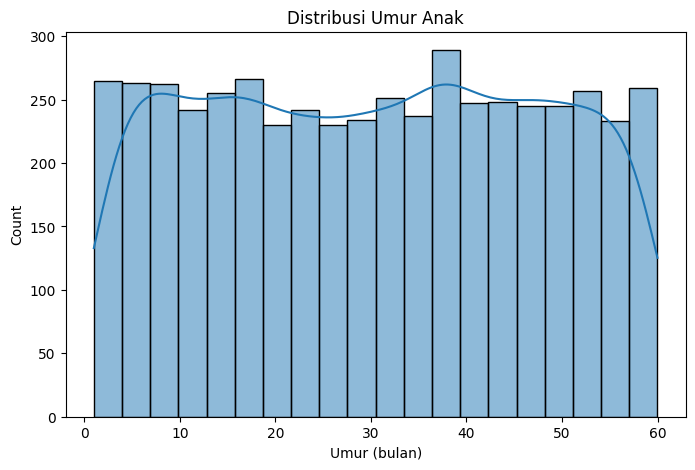

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['age_months'],
    bins=20,
    kde=True
)

plt.title('Distribusi Umur Anak')
plt.xlabel('Umur (bulan)')

plt.show()

# c. Distribusi Berat Badan

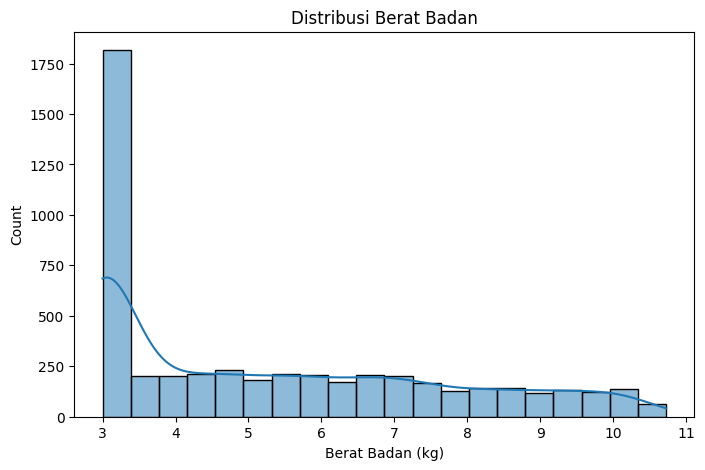

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['weight_kg'],
    bins=20,
    kde=True
)

plt.title('Distribusi Berat Badan')
plt.xlabel('Berat Badan (kg)')

plt.show()

# d. Distribusi Tinggi Badan

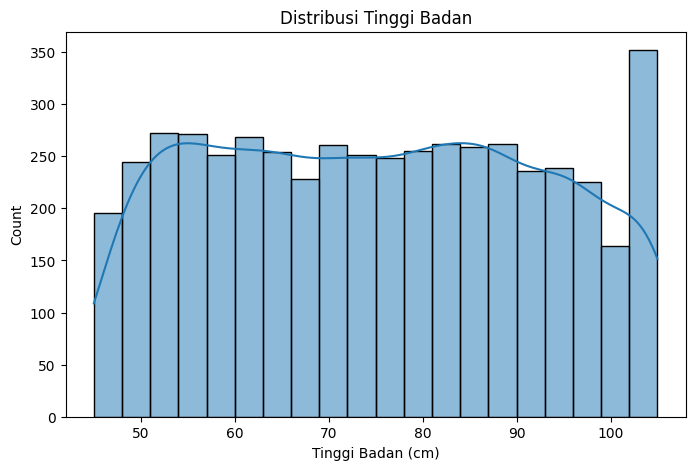

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['height_cm'],
    bins=20,
    kde=True
)

plt.title('Distribusi Tinggi Badan')
plt.xlabel('Tinggi Badan (cm)')

plt.show()

# e. Distribusi MUAC

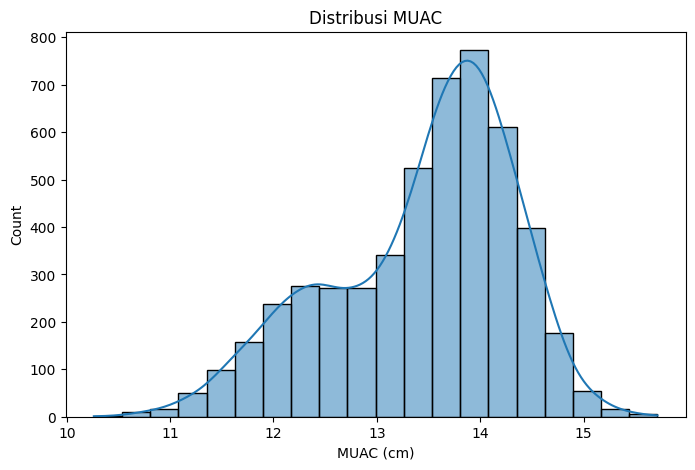

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['muac_cm'],
    bins=20,
    kde=True
)

plt.title('Distribusi MUAC')
plt.xlabel('MUAC (cm)')

plt.show()

# f. Distribusi BMI

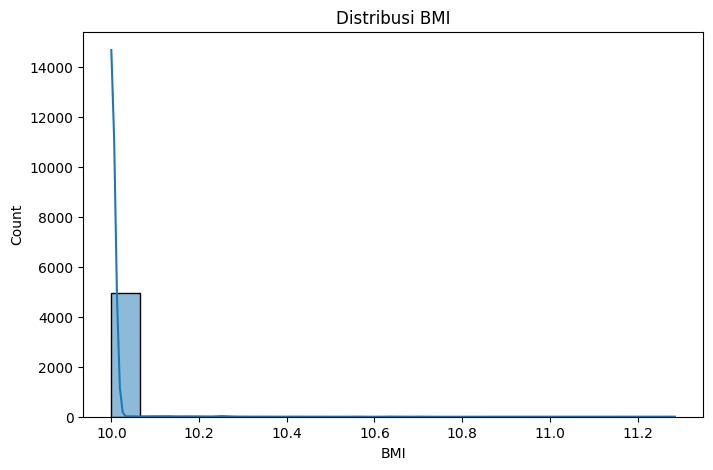

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['bmi'],
    bins=20,
    kde=True
)

plt.title('Distribusi BMI')
plt.xlabel('BMI')

plt.show()

# g. Hubungan Umur dan Berat Badan

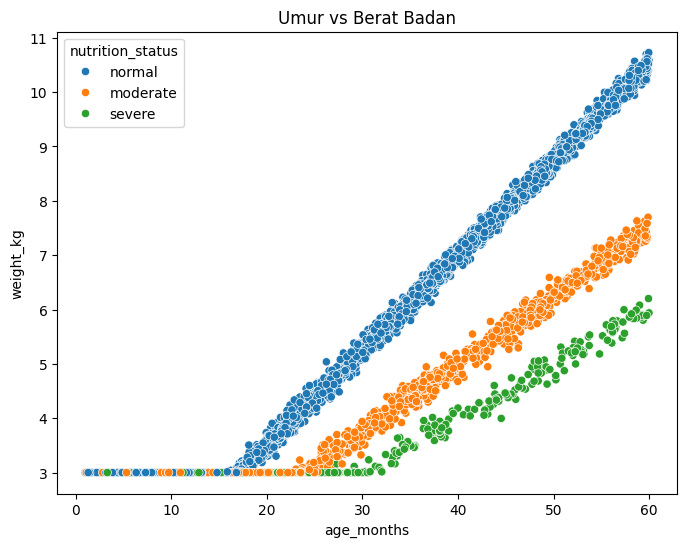

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='age_months',
    y='weight_kg',
    hue='nutrition_status'
)

plt.title('Umur vs Berat Badan')

plt.show()

# h. Hubungan Umur dan Tinggi Badan

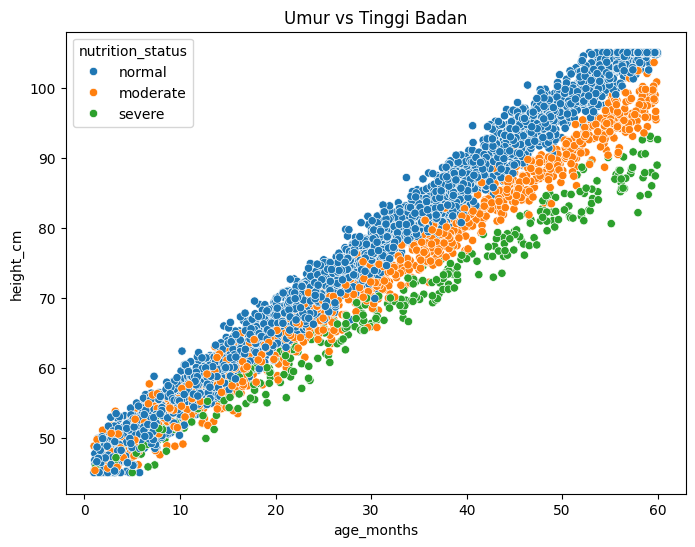

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='age_months',
    y='height_cm',
    hue='nutrition_status'
)

plt.title('Umur vs Tinggi Badan')

plt.show()

# i. Hubungan Berat Badan dan Tinggi Badan

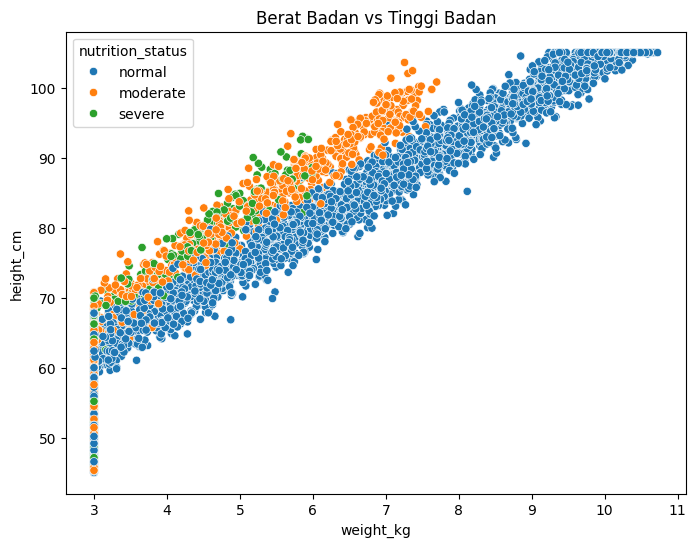

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='weight_kg',
    y='height_cm',
    hue='nutrition_status'
)

plt.title('Berat Badan vs Tinggi Badan')

plt.show()

# j. BMI Berdasarkan Status Gizi

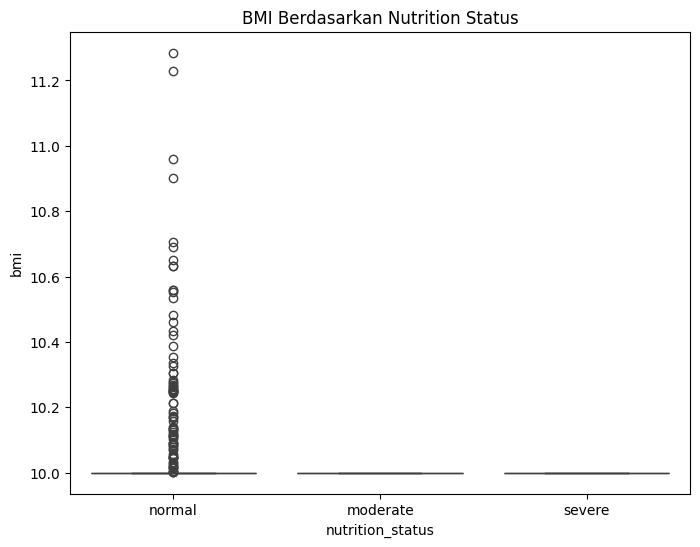

In [35]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='nutrition_status',
    y='bmi'
)

plt.title('BMI Berdasarkan Nutrition Status')

plt.show()

# k. MUAC Berdasarkan Status Gizi

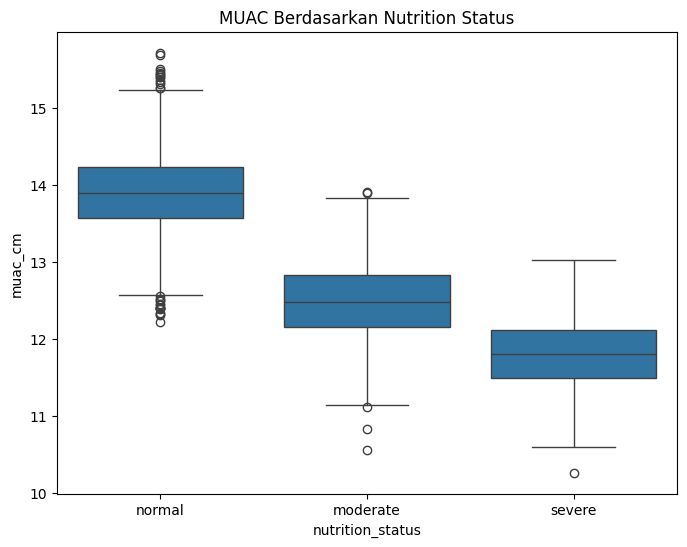

In [36]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='nutrition_status',
    y='muac_cm'
)

plt.title('MUAC Berdasarkan Nutrition Status')

plt.show()

# l. Berat Badan Berdasarkan Status Gizi

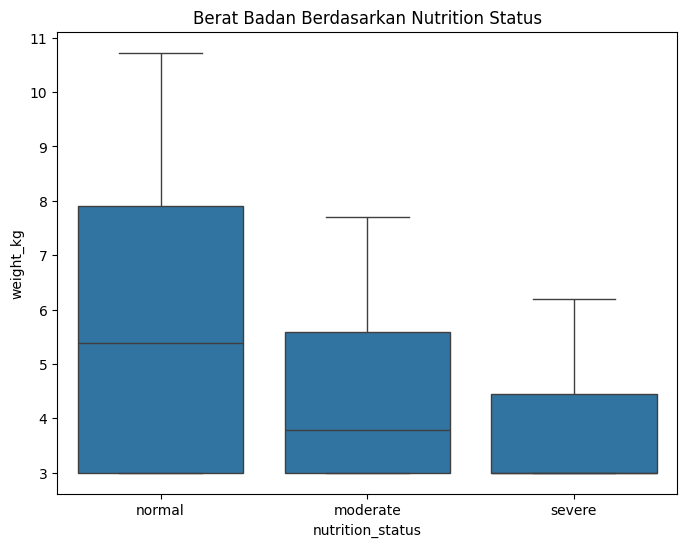

In [37]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='nutrition_status',
    y='weight_kg'
)

plt.title('Berat Badan Berdasarkan Nutrition Status')

plt.show()

# m. Tinggi Badan Berdasarkan Status Gizi

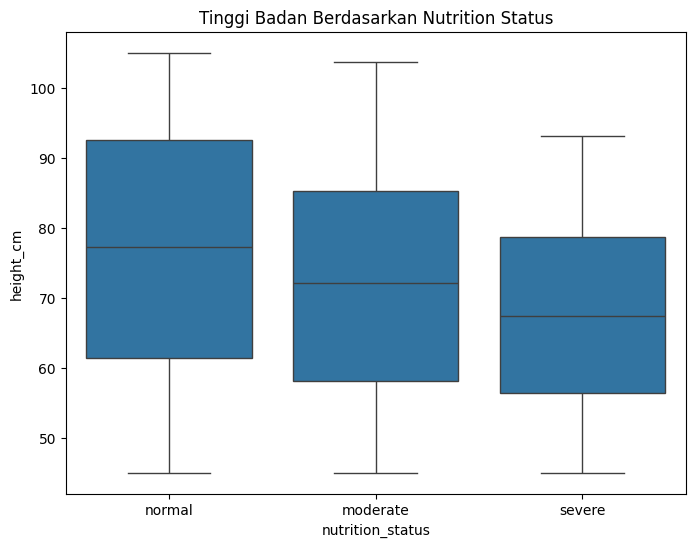

In [38]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='nutrition_status',
    y='height_cm'
)

plt.title('Tinggi Badan Berdasarkan Nutrition Status')

plt.show()

# n. Korelasi Antar Fitur Numerik

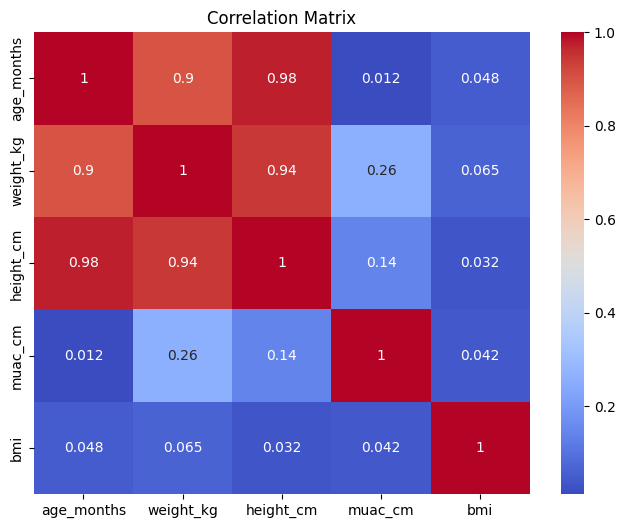

In [39]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['age_months',
        'weight_kg',
        'height_cm',
        'muac_cm',
        'bmi']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

# o. Pairplot

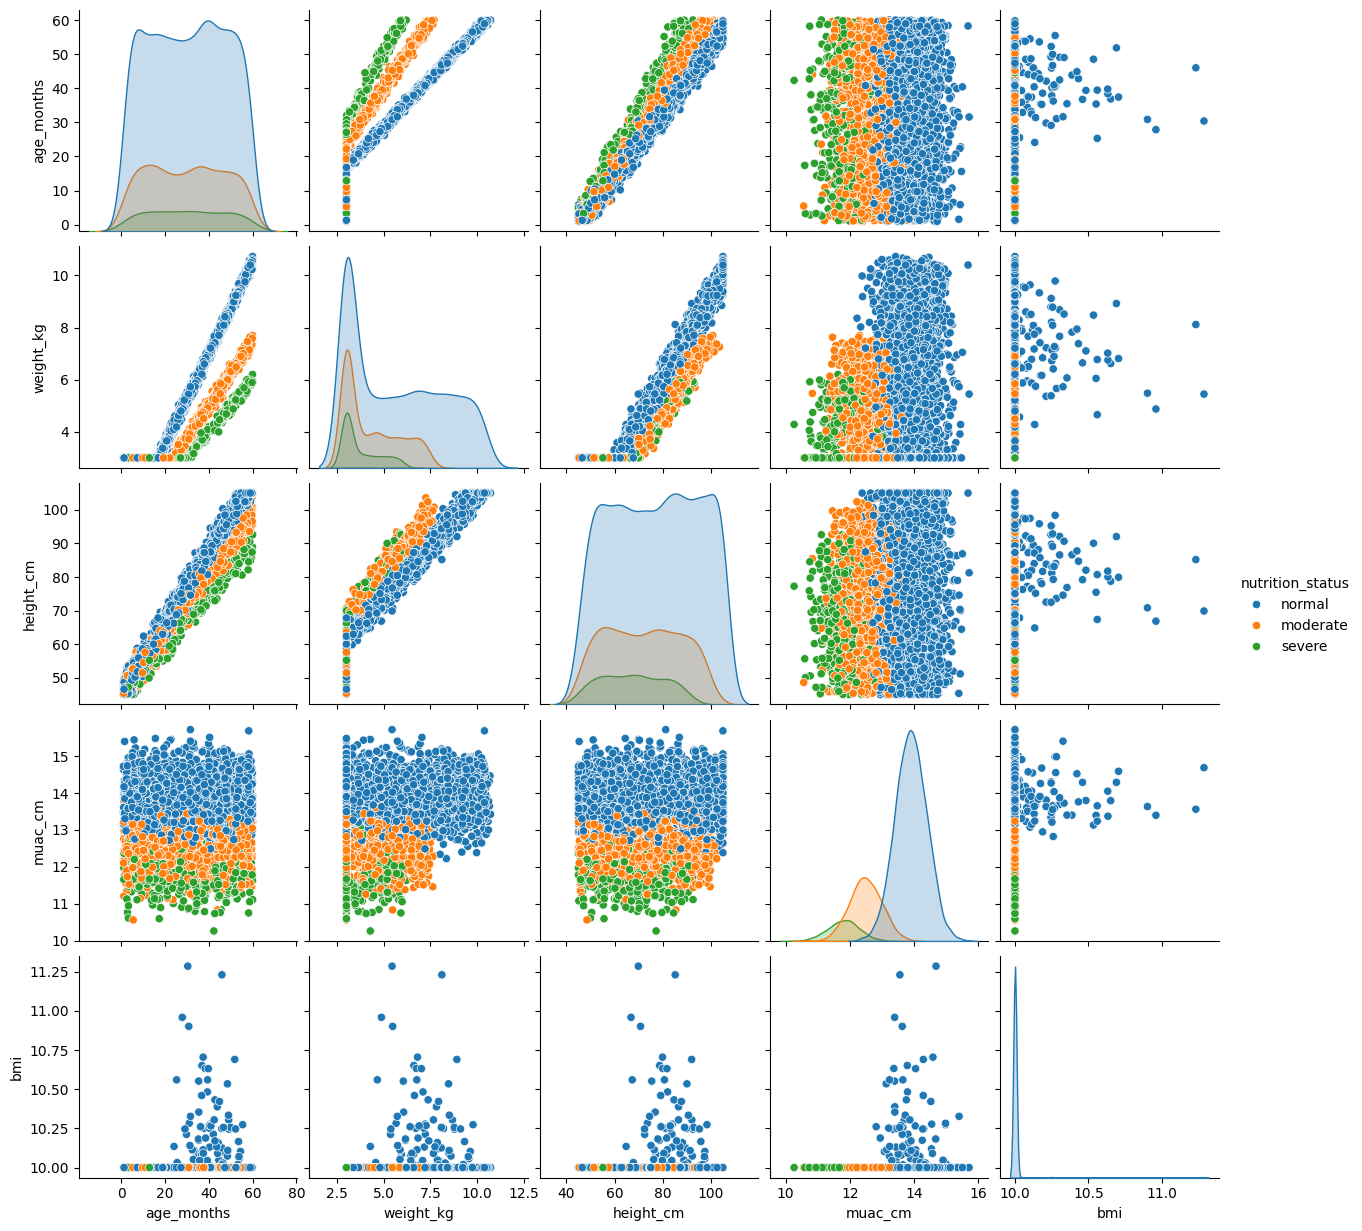

In [40]:
sns.pairplot(
    df,
    hue='nutrition_status'
)

plt.show()

## 5. Seleksi dan Persiapan Fitur

# a. Menentukan Fitur dan Target

In [123]:
X = df[['age_months',
        'weight_kg',
        'height_cm',
        'muac_cm',
        'bmi']]

y = df['nutrition_status']

# b. Melihat Bentuk Fitur dan Target

In [124]:
print(X.shape)
print(y.shape)

(5000, 5)
(5000,)


# c. Mengubah Label Target Menjadi Numerik

In [125]:
le_status = LabelEncoder()

y = le_status.fit_transform(y)

# d. Melihat Mapping Label

In [126]:
for i, label in enumerate(le_status.classes_):
    print(i, "=", label)

0 = moderate
1 = normal
2 = severe


# e. Memastikan Tidak Ada Kolom Kategorikal di Fitur

In [127]:
print(X.dtypes)

age_months    float64
weight_kg     float64
height_cm     float64
muac_cm       float64
bmi           float64
dtype: object


# f. Memeriksa Distribusi Target Setelah Encoding

In [128]:
print(pd.Series(y).value_counts())

1    3550
0    1100
2     350
Name: count, dtype: int64


# g. Menyimpan Nama Fitur

In [129]:
print(X.dtypes)

age_months    float64
weight_kg     float64
height_cm     float64
muac_cm       float64
bmi           float64
dtype: object


## 6. Pembagian Data

# a. Pembagian Data Train dan Tes

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# b. Melihat Ukuran Data Hasil Pembagian

In [131]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (4000, 5)
X_test  : (1000, 5)
y_train : (4000,)
y_test  : (1000,)


# c. Memeriksa Distribusi Kelas pada Data Training

In [132]:
print(pd.Series(y_train).value_counts())

1    2840
0     880
2     280
Name: count, dtype: int64


# d. Memeriksa Distribusi Kelas pada Data Testing

In [133]:
print(pd.Series(y_test).value_counts())

1    710
0    220
2     70
Name: count, dtype: int64


## 7, Penyeimbangan Data

# a. Melihat Distribusi Kelas Sebelum SMOTE

In [134]:
print(pd.Series(y_train).value_counts())

1    2840
0     880
2     280
Name: count, dtype: int64


# b. Membuat Objek SMOTE

In [135]:
smote = SMOTE(random_state=42)

# c. Menerapkan SMOTE pada Data Training

In [136]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# d. Melihat Distribusi Kelas Setelah SMOTE

In [137]:
print(pd.Series(y_train_smote).value_counts())

0    2840
1    2840
2    2840
Name: count, dtype: int64


/tmp/ipykernel_12708/709036684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


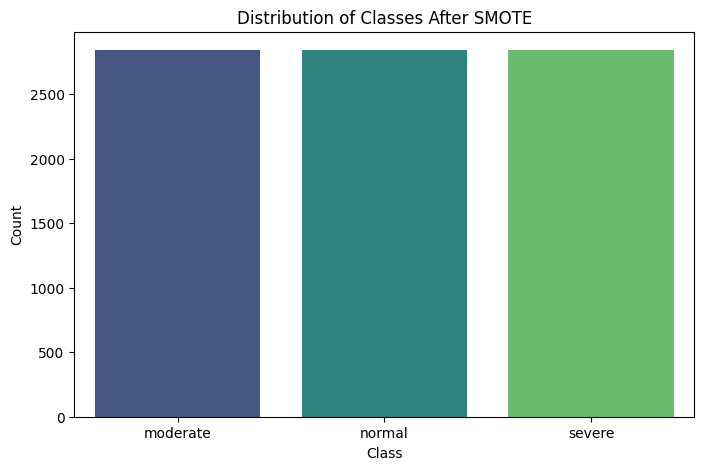

In [157]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=y_train_smote,
    palette='viridis'
)

plt.title('Distribution of Classes After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=le_status.classes_)

plt.show()

# e. Memeriksa Ukuran Data Setelah SMOTE

In [138]:
print("X_train sebelum :", X_train.shape)
print("X_train sesudah :", X_train_smote.shape)

print("y_train sebelum :", y_train.shape)
print("y_train sesudah :", y_train_smote.shape)

X_train sebelum : (4000, 5)
X_train sesudah : (8520, 5)
y_train sebelum : (4000,)
y_train sesudah : (8520,)


## 8. Pembuatan dan Pelatihan Model Decision Tree

# a. Membuat Model Decision Tree

In [139]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,
    random_state=42
)

# b. Melatih Model Menggunakan Data Hasil SMOTE

In [140]:
dt_model.fit(
    X_train_smote,
    y_train_smote
)

DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)

# c. Melihat Kelas yang Dipelajari Model

In [141]:
print(dt_model.classes_)

[0 1 2]


# e. Melihat Jumlah Fitur yang Digunakan

In [142]:
print(dt_model.n_features_in_)

5


# f. Melihat Kedalaman Pohon yang Terbentuk

In [143]:
print("Depth:", dt_model.get_depth())

Depth: 6


# g. Melihat Jumlah Node

In [144]:
print("Jumlah Node:", dt_model.tree_.node_count)

Jumlah Node: 67


# h. Melihat Jumlah Leaf

In [145]:
print("Jumlah Leaf:", dt_model.get_n_leaves())

Jumlah Leaf: 34


## 9. Prediksi

# a. Melakukan Prediksi pada Data Testing

In [146]:
y_pred = dt_model.predict(X_test)
print(y_pred[:10])

[1 2 1 0 1 1 0 1 1 1]


# b. Membandingkan Data Aktual dan Prediksi

In [147]:
hasil_prediksi = pd.DataFrame({
    'Aktual': y_test,
    'Prediksi': y_pred
})

print(hasil_prediksi.head(10))

   Aktual  Prediksi
0       1         1
1       2         2
2       1         1
3       0         0
4       1         1
5       1         1
6       0         0
7       1         1
8       1         1
9       1         1


# c. Menampilkan Prediksi yang Benar

In [67]:
hasil_prediksi[
    hasil_prediksi['Aktual'] ==
    hasil_prediksi['Prediksi']
]

,Aktual,Prediksi
0,1,1
1,2,2
2,1,1
3,0,0
4,1,1
...,...,...
995,0,0
996,1,1
997,1,1
998,1,1


# d. Menampilkan Prediksi yang Salah

In [68]:
hasil_prediksi[
    hasil_prediksi['Aktual'] !=
    hasil_prediksi['Prediksi']
]

,Aktual,Prediksi
27,1,0
30,1,0
32,0,2
33,0,1
37,1,0
...,...,...
953,2,0
955,1,0
960,1,0
970,0,2


# e. Melakukan Prediksi pada Satu Data Baru

In [148]:
data_baru = [[24, 8.5, 78, 12.5, 13.98]]

prediksi = dt_model.predict(data_baru)

print(prediksi)

hasil = le_status.inverse_transform(prediksi)

print(hasil)

[1]
['normal']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# f. Prediksi Dengan Beberapa Data Sekaligus

In [149]:
data_baru = [
    # Anak dengan berat, tinggi, dan MUAC sangat rendah
    # Diperkirakan Severe Malnutrition
    [56.10, 5.38, 85.82, 12.4, 10.0],

    # Anak dengan kondisi sedang di bawah normal
    # Diperkirakan Moderate Malnutrition
    [24, 7.0, 72, 11.8, 13.50],

    # Anak dengan pertumbuhan normal
    # Diperkirakan Normal
    [36, 12.0, 92, 14.5, 14.18],

    # Anak yang lebih besar dengan indikator normal
    # Diperkirakan Normal
    [48, 15.0, 105, 15.5, 13.61],

    # Anak dengan MUAC cukup rendah namun tidak ekstrem
    # Diperkirakan Moderate Malnutrition
    [30, 8.0, 78, 12.0, 13.15]
]

prediksi = dt_model.predict(data_baru)

hasil = le_status.inverse_transform(prediksi)

for i, status in enumerate(hasil, start=1):
    print(f"Data Anak {i}: {status}")

Data Anak 1: severe
Data Anak 2: moderate
Data Anak 3: normal
Data Anak 4: normal
Data Anak 5: moderate


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## 10. Evaluasi Model

# a. Menghitung Accuracy

In [150]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 88.10%


# b. Membuat Confusion Matrix

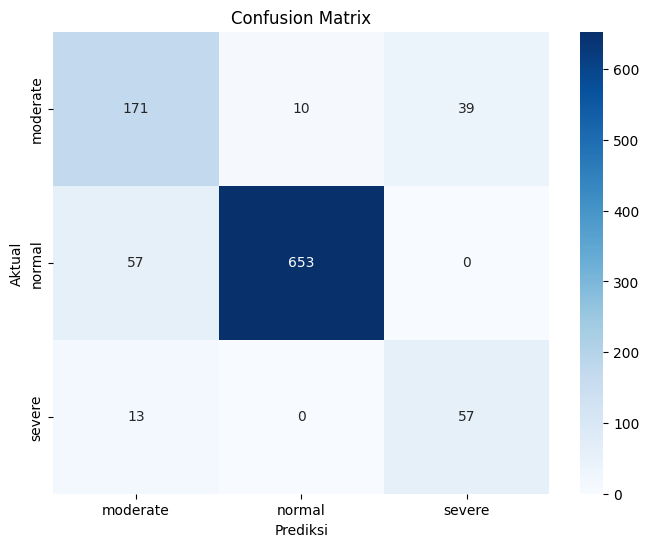

In [80]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_status.classes_,
    yticklabels=le_status.classes_
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')

plt.show()

# c. Membuat Classification Report

In [151]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le_status.classes_
    )
)

              precision    recall  f1-score   support

    moderate       0.71      0.78      0.74       220
      normal       0.98      0.92      0.95       710
      severe       0.59      0.81      0.69        70

    accuracy                           0.88      1000
   macro avg       0.76      0.84      0.79      1000
weighted avg       0.90      0.88      0.89      1000



# d. Menampilkan Seluruh Metrik Sekaligus

In [152]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 0.881
Precision: 0.8969531861180476
Recall   : 0.881
F1 Score : 0.8866359423820634


# e. Membandingkan Accuracy

In [153]:
train_pred = dt_model.predict(X_train_smote)

print(
    "Training Accuracy:",
    accuracy_score(y_train_smote, train_pred)
)

print(
    "Testing Accuracy:",
    accuracy_score(y_test, y_pred)
)

Training Accuracy: 0.8778169014084507
Testing Accuracy: 0.881


# f. Visualisasi Decision Tree

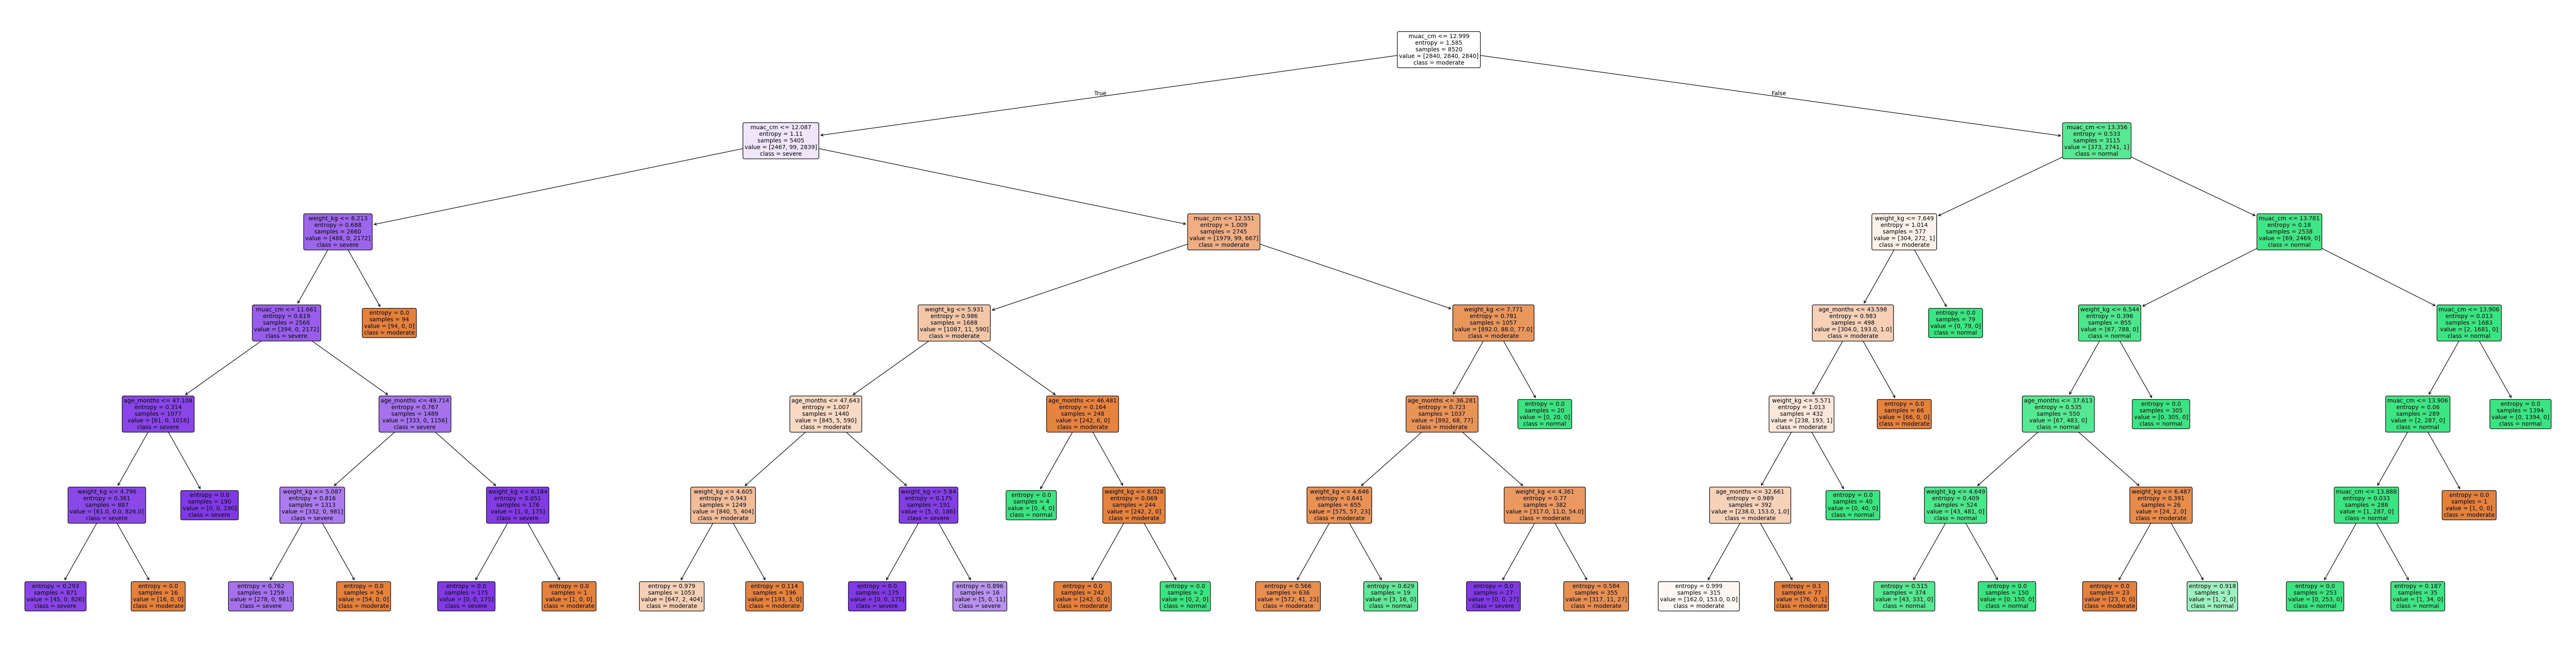

In [86]:
plt.figure(figsize=(80, 20))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=le_status.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

# 11. Analisis Feature Importance

# a. Menampilkan Feature Importance

In [156]:
for fitur, importance in zip(X.columns, dt_model.feature_importances_):
    print(f"{fitur}: {importance:.2f}")

age_months: 0.06
weight_kg: 0.12
height_cm: 0.00
muac_cm: 0.83
bmi: 0.00


In [94]:
importance_df = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': dt_model.feature_importances_
})

print(importance_df)

        Fitur  Importance
0  age_months    0.055713
1   weight_kg    0.117867
2   height_cm    0.000000
3     muac_cm    0.826420
4         bmi    0.000000


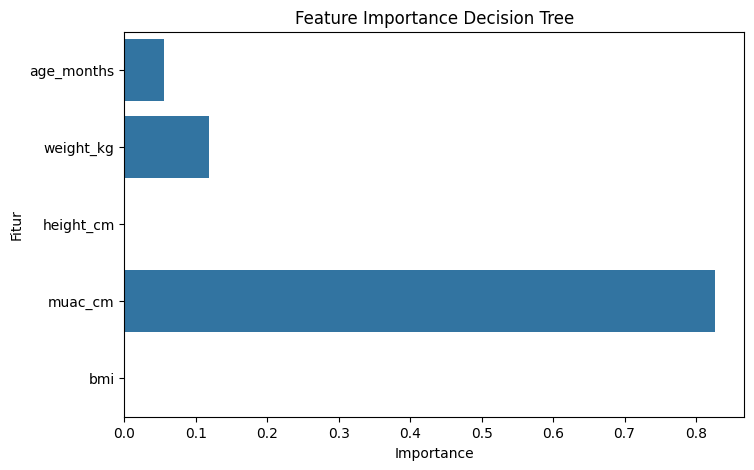

In [95]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Fitur'
)

plt.title('Feature Importance Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Fitur')

plt.show()

## 12. Kesimpulan

Hasil analisis feature importance menunjukkan bahwa fitur MUAC memiliki kontribusi terbesar dalam proses klasifikasi status gizi anak. Fitur weight_kg dan age_months juga memberikan kontribusi terhadap pengambilan keputusan model. Sementara itu, fitur height_cm memiliki nilai importance sebesar 0, yang menunjukkan bahwa fitur tersebut tidak digunakan dalam pembentukan pohon keputusan. Hal ini diduga karena height_cm memiliki korelasi yang sangat tinggi dengan age_months (0,98) dan weight_kg (0,94), sehingga informasi yang dibawanya telah terwakili oleh fitur lain yang dipilih model. Dengan demikian, meskipun height_cm berkaitan dengan status gizi, fitur tersebut tidak memberikan tambahan informasi yang signifikan bagi model Decision Tree yang dibangun.